<a href="https://colab.research.google.com/github/vsaludesm/Visualizacion_USAL/blob/main/Visualizaci%C3%B3n_VSaludes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# Importación de Pandas
import pandas as pd

In [8]:
# Carga del Conjunto de Datos
df = pd.read_csv ('https://raw.githubusercontent.com/vsaludesm/Visualizacion_USAL/main/Datos_Visualizacion_2022-2025.csv', delimiter=';')

In [18]:
# Generar un DataFrame con las frecuencias de 'Sublinaje_MTBC_Vis' por 'Fecha_toma_muestra_Vis'

# Definir una función para extraer año y trimestre para ordenar
def sort_quarters(quarter_str):
    if pd.isna(quarter_str): # Handle potential NaN values if any
        return (0, 0) # Place NaN at the beginning
    parts = quarter_str.split('_')
    q_num = int(parts[0][0])
    year = int(parts[1])
    return (year, q_num)

# Obtener el orden deseado de los trimestres
# Usar el índice de frecuencias_df directamente para asegurar que solo se usan los trimestres presentes
all_quarters = sorted(df['Fecha_toma_muestra_Vis'].dropna().unique().tolist(), key=sort_quarters)

# Convertir la columna 'Fecha_toma_muestra_Vis' a tipo categórico con el orden deseado
df['Fecha_toma_muestra_Vis'] = pd.Categorical(df['Fecha_toma_muestra_Vis'], categories=all_quarters, ordered=True)

frecuencias_df = pd.crosstab(df['Fecha_toma_muestra_Vis'], df['Sublinaje_MTBC_Vis'])

# Mostrar las primeras filas del nuevo DataFrame de frecuencias
display(frecuencias_df.head())

Sublinaje_MTBC_Vis,L1,L2,L3,L4.1.2.1,L4.3.2,L4.3.3,L4.3.4.2,L4.8,L4_minor,L5_6,La,La1.BCG
Fecha_toma_muestra_Vis,,,,,,,,,,,,
1T_2022,4,4,5,34,16,13,18,21,35,5,1,2
2T_2022,8,5,9,29,29,8,8,22,32,2,0,3
3T_2022,1,5,8,40,12,12,4,15,28,1,2,0
4T_2022,2,7,11,23,17,10,5,23,29,4,0,0
1T_2023,2,3,14,30,26,15,8,21,38,3,4,1


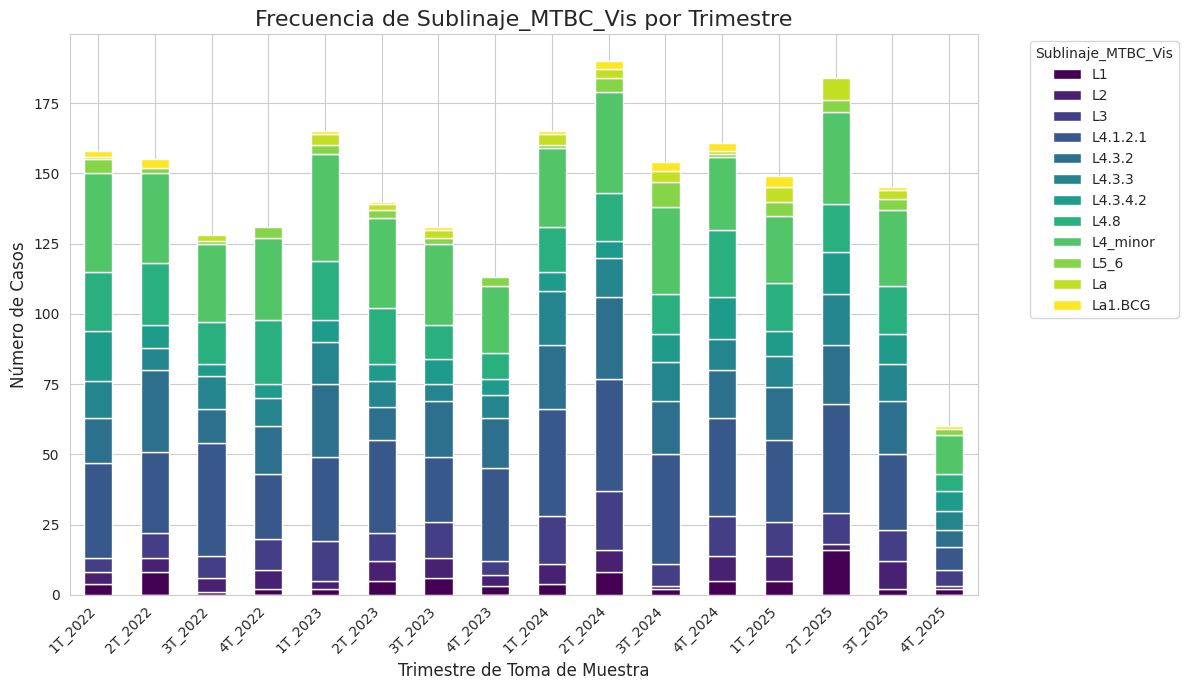

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Establecer un estilo para los gráficos (opcional, mejora la estética)
sns.set_style("whitegrid")

# Crear un gráfico de barras apiladas
fig, ax = plt.subplots(figsize=(12, 7)) # Ajustar el tamaño de la figura para mejor visibilidad

frecuencias_df.plot(kind='bar', stacked=True, ax=ax, cmap='viridis')

# Añadir título y etiquetas
ax.set_title('Frecuencia de Sublinaje_MTBC_Vis por Trimestre', fontsize=16)
ax.set_xlabel('Trimestre de Toma de Muestra', fontsize=12)
ax.set_ylabel('Número de Casos', fontsize=12)

# Establecer explícitamente los ticks del eje X para mostrar todos los trimestres
ax.set_xticks(range(len(frecuencias_df.index)))
ax.set_xticklabels(frecuencias_df.index, rotation=45, ha='right')

# Mover la leyenda fuera del gráfico para que no lo tape
ax.legend(title='Sublinaje_MTBC_Vis', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout() # Ajustar el diseño para evitar que las etiquetas se corten
plt.show()

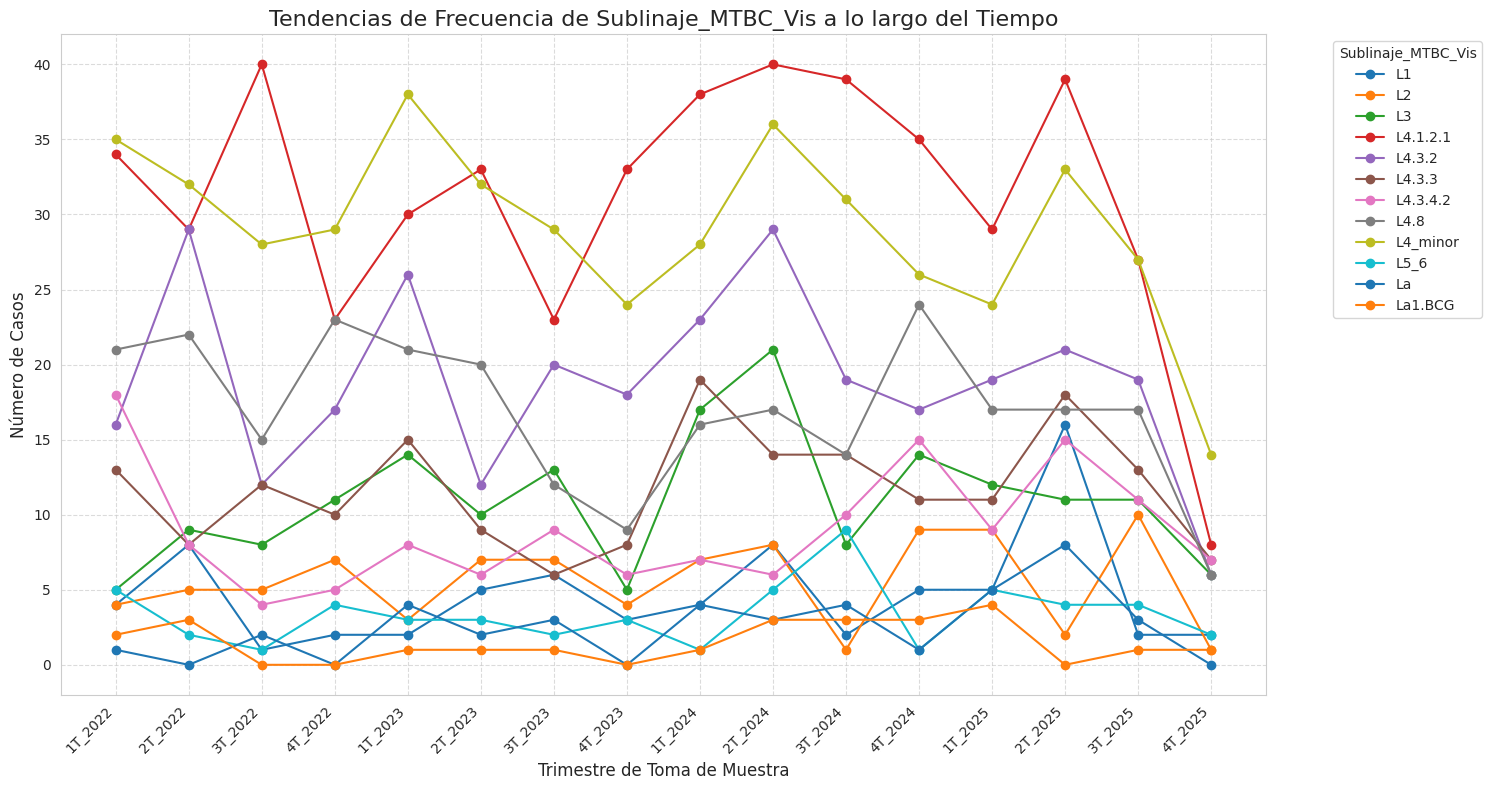

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Crear un gráfico de líneas para observar tendencias temporales
fig, ax = plt.subplots(figsize=(15, 8)) # Ajustar el tamaño de la figura

frecuencias_df.plot(kind='line', ax=ax, marker='o') # Usar kind='line' y añadir marcadores

# Añadir título y etiquetas
ax.set_title('Tendencias de Frecuencia de Sublinaje_MTBC_Vis a lo largo del Tiempo', fontsize=16)
ax.set_xlabel('Trimestre de Toma de Muestra', fontsize=12)
ax.set_ylabel('Número de Casos', fontsize=12)

# Establecer explícitamente los ticks del eje X para mostrar todos los trimestres
ax.set_xticks(range(len(frecuencias_df.index)))
ax.set_xticklabels(frecuencias_df.index, rotation=45, ha='right')

# Mover la leyenda fuera del gráfico para que no lo tape
ax.legend(title='Sublinaje_MTBC_Vis', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, linestyle='--', alpha=0.7) # Añadir una cuadrícula para mejor lectura
plt.tight_layout() # Ajustar el diseño
plt.show()